# Simulated IRFs from RBC Model

This code creates a very simple RBC model with random technology shocks. Data from this model is simulated, the true IRFs are created, and then the IRFs are estimated using VAR, LP, and SLP estimation.

The model has period utility $u_t=\log(C_t)$, production function $Y_t = e^{z_t}K^{\alpha}_t$, technology evolution $z_t = \rho z_{t-1}+\varepsilon_t$ with $\varepsilon_t \sim \mathcal N(0,\sigma^2)$, and resource constraint $C_t+K_{t+1}=Y_t$. The econometrician observes $K_t, Y_t, Z_t$ with noise, where $Z_t=e^{z_t}$. The advantage of this simple model (with full depreciation, inelastic labour, and log utility) is that the policy function of the household has a closed-form solution.

In [17]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [18]:
# set parameters
beta = 0.99 # quarterly discount factor
alpha = 0.33 # capital share in production function
rho = 0.9 # persistence of technology shock
sigma_z = 0.05 # standard deviation of technology shock
sigma_obs = 0.025 # standard deviation of measurement error in observed data
q = 20 # number of quarters for IRF
T = 200 # number of quarters for simulated data

np.random.seed(1371) # set seed for reproducibility

In [19]:
# IRF plotting function
def plot_irf(data, title):
    data.rename(columns={0: 'Capital', 1: 'Output', 2: 'Technology'}, inplace=True)
    varnames = data.columns
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(2, 3, i+1)
        plt.plot(data[varnames[i]])
        plt.title(f'Technology -> {varnames[i]}')
        plt.xlabel('Periods')
        plt.ylabel('Response')
        plt.axhline(0, color='black', linestyle='dashed')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

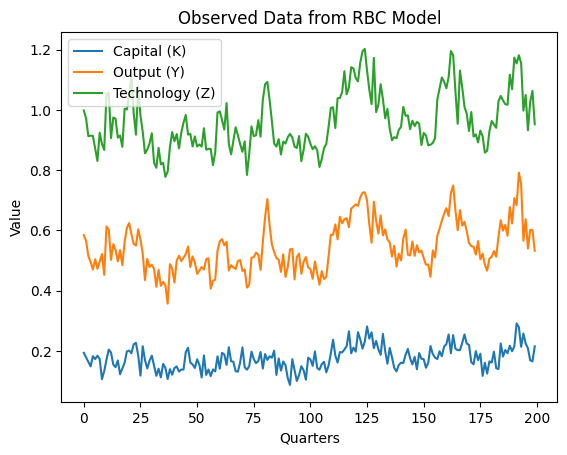

In [20]:
# create simulated time series data for simple RBC model
def gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(T)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    K[0] = ss_K
    C[0] = ss_C
    Y[0] = K[0]**alpha

    for t in range(1, T):
        z[t] = rho * z[t-1] + sigma_z * np.random.normal()
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha # closed-form solution for capital accumulation
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha # closed-form solution for consumption
        
    Z = np.exp(z) + np.random.normal(0, sigma_obs, size=T) # add measurement error
    Y = Z*K**alpha + np.random.normal(0, sigma_obs, size=T) # add measurement error
    K = K + np.random.normal(0, sigma_obs, size=T) # add measurement error

    return pd.DataFrame({"Capital": K, "Output": Y, "Technology": Z})

observed_data = gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from RBC Model")
plt.xlabel("Quarters")
plt.ylabel("Value")
plt.legend(["Capital (K)", "Output (Y)", "Technology (Z)"])
plt.show()

### Generating the true IRFs

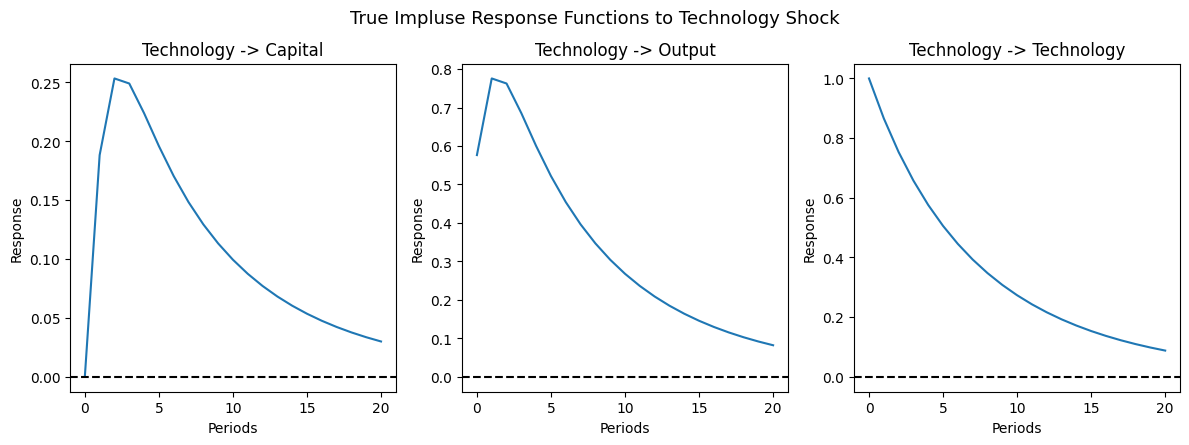

In [21]:
# true IRF for a unit technology shock
# this is the true IRF that the econometrician is trying to estimate from observed data
def gen_irf(beta, alpha, rho, q):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(q+1)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    z[0] = np.log(2) # unit shock to Z
    K[0] = ss_K
    C[0] = ss_C

    for t in range(1, q+1):
        z[t] = rho * z[t-1]
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha

    Z = np.exp(z) - 1
    Y = np.exp(z)*K**alpha - ss_K**alpha
    K = K - ss_K

    return pd.DataFrame({"Capital": K, "Output": Y, "Technology": Z})

true_irf = gen_irf(beta, alpha, rho, q)

plot_irf(true_irf, 'True Impluse Response Functions to Technology Shock')

### Estimating the IRFs using VAR

AIC optimal lags: 2


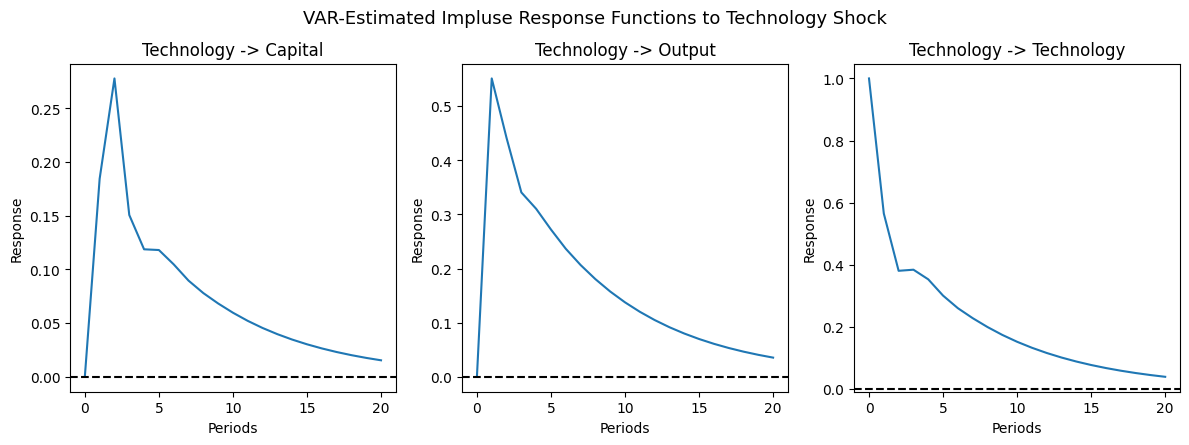

In [22]:
# VAR estimation of IRFs
model = VAR(observed_data)
var_results = model.fit(ic="aic")
irfs = var_results.irf(periods=q).irfs
var = pd.DataFrame(irfs[:,:,2])

print("AIC optimal lags:", model.select_order(maxlags=10).aic) # optimal lags from AIC - used for VAR, LP, and SLP estimation

plot_irf(var, 'VAR-Estimated Impluse Response Functions to Technology Shock')

### Estimating the IRFs using local projections

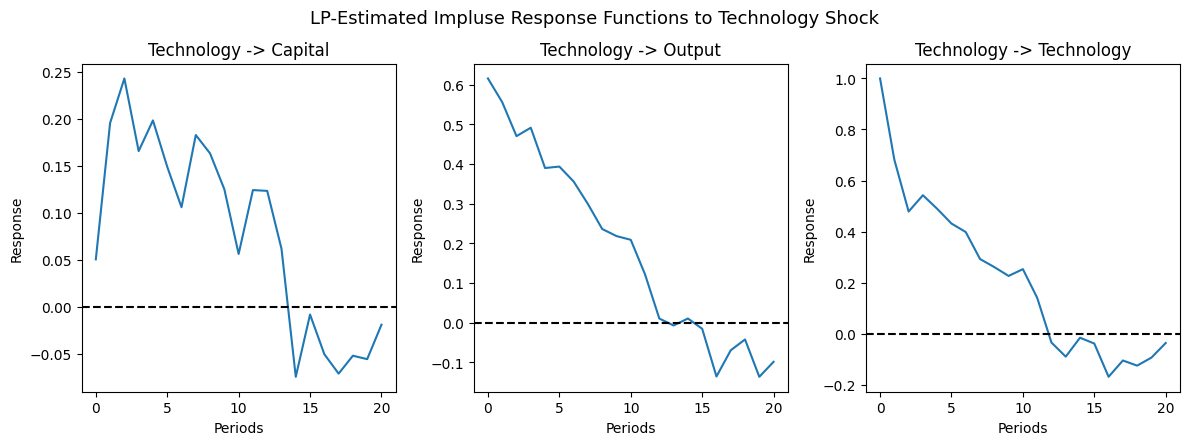

In [23]:
# estimating IRF using LPs on observed data
LP_model = SmoothLocalProjections(observed_data, "Technology", None, True, 2, q) # same lags as VAR
LP = pd.DataFrame(LP_model.LP().beta)

plot_irf(LP, 'LP-Estimated Impluse Response Functions to Technology Shock')

### Estimating the IRFs using smooth local projections

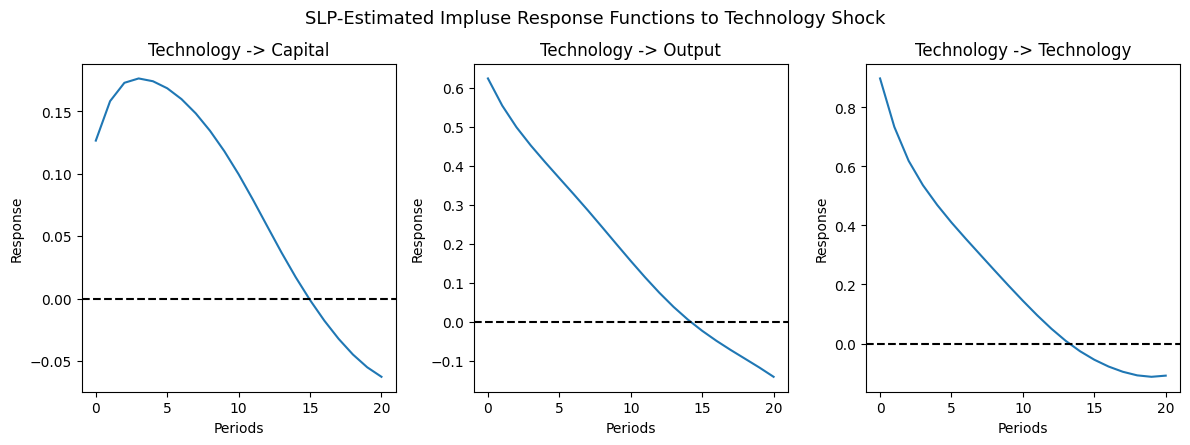

In [24]:
# estimating IRF using SLPs on observed data
SLP_model = SmoothLocalProjections(observed_data, "Technology", None, True, 2, q) # same lags as VAR
SLP = pd.DataFrame(SLP_model.SLP().beta)

plot_irf(SLP, 'SLP-Estimated Impluse Response Functions to Technology Shock')

### Discussion